# CS Kernel Bands

Build the full Collins-Soper kernel from:
- a fit card under `../Cards/`
- a parameter ensemble CSV
- the perturbative kernel grid in `extracted CS/CS_Pert.csv`
- the NP form from the corresponding file under `../TMDs/NP Parameterizations Julia/`

The notebook exports one CSV with the central curve from the card and the central 68% replica band.
If you switch to a different card, restart the kernel before rerunning the Julia setup cell.


In [1]:
from julia import Main

import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from tqdm.auto import tqdm

plt.rcParams["figure.dpi"] = 120


c:\Users\congyue zhang\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
card_path = Path("../Cards/Final_old.jl")
#parameter_csv_path = Path("../Bayesian Analysis/bayesian parameters/bayesian_parameters.csv")
parameter_csv_path = Path("../FitS/replica_data/replica_0325.csv")
cs_pert_path = Path("extracted CS/CS_Pert.csv")
output_csv_dir = Path("extracted CS")
output_csv_name = "replica_0325.csv"
preview_plot_dir = Path("CS kernel")
preview_plot_name = None

use_success_only = True
max_replicas = None
target_Q = None
band_alpha = 0.15865
x_reference = 0.1  # Only used to access NP_f_func; SNP_zeta is expected to be x-independent.
show_plot = True


In [3]:
card_path = card_path.resolve()
parameter_csv_path = parameter_csv_path.resolve()
cs_pert_path = cs_pert_path.resolve()
output_csv_dir = output_csv_dir.resolve()
preview_plot_dir = preview_plot_dir.resolve()
output_csv_dir.mkdir(parents=True, exist_ok=True)
preview_plot_dir.mkdir(parents=True, exist_ok=True)

fit_name = card_path.stem
repo_root = card_path.parents[1]

if not card_path.exists():
    raise FileNotFoundError(f"Missing card: {card_path}")
if not parameter_csv_path.exists():
    raise FileNotFoundError(f"Missing parameter CSV: {parameter_csv_path}")
if not cs_pert_path.exists():
    raise FileNotFoundError(f"Missing perturbative CS CSV: {cs_pert_path}")

card_text = card_path.read_text(encoding="utf-8")

struct_match = re.search(r"struct\s+Params_Struct(.*?)end", card_text, re.S)
if struct_match is None:
    raise ValueError(f"Could not find Params_Struct in {card_path}")

param_names = re.findall(
    r"([A-Za-z_][A-Za-z0-9_]*)\s*::\s*Float32",
    struct_match.group(1),
)
param_columns = [f"param_{i}" for i in range(len(param_names))]

init_matches = re.findall(r"(?ms)^\s*initial_params\s*=\s*\[([^\]]*)\]", card_text)
if not init_matches:
    raise ValueError(f"Could not find initial_params in {card_path}")

initial_params = np.asarray(
    [float(x) for x in re.findall(r"-?\d+(?:\.\d+)?(?:[eE][+-]?\d+)?", init_matches[-1])],
    dtype=float,
)

frozen_match = re.search(r"frozen_indices\s*=\s*\[([^\]]*)\]", card_text)
frozen_idx = (
    np.asarray([int(x) for x in re.findall(r"-?\d+", frozen_match.group(1))], dtype=int)
    if frozen_match
    else np.asarray([], dtype=int)
)
frozen_set = set(frozen_idx.tolist())

np_name_match = re.search(r'const\s+NP_name\s*=\s*"([^"]+)"', card_text)
if np_name_match is None:
    raise ValueError(f"Could not find NP_name in {card_path}")
np_cl_name = np_name_match.group(1)
np_julia_name = Path(np_cl_name).with_suffix(".jl").name
np_julia_path = repo_root / "TMDs" / "NP Parameterizations Julia" / np_julia_name
if not np_julia_path.exists():
    raise FileNotFoundError(f"No Julia NP file found for {np_cl_name}: {np_julia_path}")

if output_csv_name is None:
    output_csv_name = f"{fit_name}_{parameter_csv_path.stem}_CS_band_68.csv"
if preview_plot_name is None:
    preview_plot_name = f"{fit_name}_{parameter_csv_path.stem}_CS_band_preview.pdf"

output_band_csv_path = output_csv_dir / output_csv_name
preview_plot_path = preview_plot_dir / preview_plot_name

def load_parameter_ensemble(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    if df.empty:
        raise ValueError(f"{path} does not contain any rows")

    working = df.copy()

    if all(col in working.columns for col in param_columns):
        for col in param_columns:
            working[col] = pd.to_numeric(working[col], errors="coerce")
        for col, name in zip(param_columns, param_names):
            working[name] = working[col]
    elif all(name in working.columns for name in param_names):
        for name in param_names:
            working[name] = pd.to_numeric(working[name], errors="coerce")
    else:
        raise ValueError(
            f"{path} must contain either {param_columns} or the named parameter columns {param_names}"
        )

    if "replica_id" not in working.columns:
        working["replica_id"] = np.arange(len(working), dtype=int)
    if "success" not in working.columns:
        working["success"] = 1
    if "nfev" not in working.columns:
        working["nfev"] = pd.Series(pd.array([pd.NA] * len(working), dtype="Int64"), index=working.index)
    if "best_chi2dN" not in working.columns:
        working["best_chi2dN"] = np.nan
    if "pdf_replica_id" not in working.columns:
        working["pdf_replica_id"] = pd.Series(pd.array([pd.NA] * len(working), dtype="Int64"), index=working.index)

    working["replica_id"] = pd.to_numeric(working["replica_id"], errors="coerce")
    working["success"] = pd.to_numeric(working["success"], errors="coerce").astype("Int64")
    working["nfev"] = pd.to_numeric(working["nfev"], errors="coerce").astype("Int64")
    working["best_chi2dN"] = pd.to_numeric(working["best_chi2dN"], errors="coerce")
    working["pdf_replica_id"] = pd.to_numeric(working["pdf_replica_id"], errors="coerce").astype("Int64")

    working = working.dropna(subset=["replica_id", *param_names]).copy()
    working["replica_id"] = working["replica_id"].astype(int)
    return working.sort_values("replica_id").reset_index(drop=True)

replica_results_all_df = load_parameter_ensemble(parameter_csv_path)
replica_results_df = replica_results_all_df.copy()
if use_success_only:
    replica_results_df = replica_results_df[replica_results_df["success"].fillna(0) == 1].reset_index(drop=True)
if max_replicas is not None:
    replica_results_df = replica_results_df.head(max_replicas).copy()
if replica_results_df.empty:
    raise ValueError("No parameter rows available after filtering")

param_info_df = pd.DataFrame(
    {
        "index": np.arange(len(param_names), dtype=int),
        "parameter": param_names,
        "initial_value": initial_params,
        "frozen": [i in frozen_set for i in range(len(param_names))],
    }
)

display(param_info_df)
print(f"fit_name = {fit_name}")
print(f"parameter CSV = {parameter_csv_path}")
print(f"replicas used = {len(replica_results_df)} / {len(replica_results_all_df)}")
print(f"use_success_only = {use_success_only}")
print(f"NP Julia file = {np_julia_path.name}")

preview_cols = ["replica_id", "best_chi2dN", *param_names[: min(4, len(param_names))]]
display(replica_results_df[preview_cols].head())


,index,parameter,initial_value,frozen
0,0,lambda1,0.016432,False
1,1,lambda2,1.032020,False
2,2,lambda3,-2.363244,False
3,3,logx0,-5.168420,False
4,4,sigx,1.097647,False
5,5,amp,-0.472722,False
6,6,BNP,1.528641,False
7,7,c0,0.069849,False
8,8,c1,0.028185,False


fit_name = Final_old
parameter CSV = C:\Users\congyue zhang\Desktop\OpenCL fitter\TMD-Fits-Minimal\Fits\replica_data\replica_0325.csv
replicas used = 80 / 100
use_success_only = True
NP Julia file = NP-BroadBump42LogGaussAlpha1NoLambda2.jl


,replica_id,best_chi2dN,lambda1,lambda2,lambda3,logx0
0,0,1.775060,-0.031443,1.088764,-2.359929,-5.408433
1,1,1.828388,0.014120,1.039218,-2.675658,-5.551660
2,2,1.995664,0.001420,1.166254,-2.777019,-5.382196
3,3,1.731992,-0.040958,0.849377,-1.730298,-5.336844
4,4,2.054848,0.019749,1.022390,-2.210232,-4.957544


In [4]:
def include_path(path: Path) -> None:
    Main.eval(f'include(raw"{path.resolve().as_posix()}")')

def push_params(params: np.ndarray) -> None:
    lines = [f"global NP_{name} = Float32({float(val)})" for name, val in zip(param_names, params)]
    Main.eval("\n".join(lines))

include_path(card_path)

julia_param_names = [str(x) for x in Main.eval("collect(fieldnames(Params_Struct))")]
if julia_param_names != param_names:
    raise ValueError(f"Julia card parameters do not match parsed parameters: {julia_param_names} != {param_names}")

try:
    Main.eval("b0")
except Exception:
    Main.eval("const b0 = 1.1229189")

include_path(np_julia_path)
push_params(initial_params)

Main.eval(
    '''
    function __cs_bands_snp_zeta_grid(b_values::Vector{Float64}, x_probe::Float64)
        out = Vector{Float64}(undef, length(b_values))
        @inbounds for i in eachindex(b_values)
            out[i] = Float64(last(NP_f_func(x_probe, b_values[i])))
        end
        return out
    end
    '''
)

def evaluate_snp_zeta_grid(params: np.ndarray, b_values: np.ndarray, x_probe: float = x_reference) -> np.ndarray:
    push_params(np.asarray(params, dtype=float))
    return np.asarray(
        Main.__cs_bands_snp_zeta_grid([float(b) for b in b_values], float(x_probe)),
        dtype=float,
    )

print("Julia NP setup complete.")
print("If you switch to a different card, restart the kernel before rerunning this cell.")


Julia NP setup complete.
If you switch to a different card, restart the kernel before rerunning this cell.


In [5]:
cs_pert_df = pd.read_csv(cs_pert_path)
required_columns = {"b", "Q", "CS_Pert"}
missing_columns = required_columns.difference(cs_pert_df.columns)
if missing_columns:
    raise ValueError(f"{cs_pert_path} is missing columns: {sorted(missing_columns)}")

for col in ["b", "Q", "CS_Pert"]:
    cs_pert_df[col] = pd.to_numeric(cs_pert_df[col], errors="coerce")

cs_pert_df = cs_pert_df.dropna(subset=["b", "Q", "CS_Pert"]).copy()
available_q = np.sort(cs_pert_df["Q"].unique())
if target_Q is None:
    if len(available_q) != 1:
        raise ValueError(f"CS_Pert.csv contains multiple Q values {available_q}; set target_Q explicitly")
    target_Q = float(available_q[0])

cs_pert_df = cs_pert_df[np.isclose(cs_pert_df["Q"], float(target_Q))].copy()
if cs_pert_df.empty:
    raise ValueError(f"No CS_Pert rows found at Q={target_Q}")

cs_pert_df = cs_pert_df.sort_values("b").drop_duplicates(subset=["b"], keep="first").reset_index(drop=True)
b_grid = cs_pert_df["b"].to_numpy(dtype=float)
cs_pert_values = cs_pert_df["CS_Pert"].to_numpy(dtype=float)

display(cs_pert_df.head())
print(f"Loaded {len(cs_pert_df)} perturbative grid points at Q={target_Q:g} GeV")


,b,Q,CS_Pert
0,0.001000,2.0,-0.442049
1,0.001004,2.0,-0.441888
2,0.001033,2.0,-0.440770
3,0.001111,2.0,-0.437856
4,0.001264,2.0,-0.432637


Loaded 100 perturbative grid points at Q=2 GeV


In [6]:
central_snp_zeta = evaluate_snp_zeta_grid(initial_params, b_grid)
central_np_contribution = central_snp_zeta
central_kernel = cs_pert_values - central_np_contribution

replica_kernel_samples = np.empty((len(replica_results_df), len(b_grid)), dtype=float)

for i, row in enumerate(
    tqdm(replica_results_df.itertuples(index=False), total=len(replica_results_df), desc="Evaluating CS replicas")
):
    params = np.asarray([getattr(row, name) for name in param_names], dtype=float)
    replica_snp_zeta = evaluate_snp_zeta_grid(params, b_grid)
    replica_kernel_samples[i, :] = cs_pert_values - replica_snp_zeta

q_lo, q_mid, q_hi = np.quantile(
    replica_kernel_samples,
    [band_alpha, 0.5, 1.0 - band_alpha],
    axis=0,
)

kernel_band_df = pd.DataFrame(
    {
        "b": b_grid,
        "Q": np.full(len(b_grid), float(target_Q)),
        "CS_Pert": cs_pert_values,
        "CS_NP_central": central_np_contribution,
        "CS_central": central_kernel,
        "CS_replica_median": q_mid,
        "CS_band_lo_68": q_lo,
        "CS_band_hi_68": q_hi,
    }
)

display(kernel_band_df.head())
print(f"Built CS kernel band from {len(replica_results_df)} parameter rows")
print(f"Central 68% interval = [{band_alpha:.5f}, {1.0 - band_alpha:.5f}]")


Evaluating CS replicas: 100%|██████████| 80/80 [00:00<00:00, 784.31it/s]


,b,Q,CS_Pert,CS_NP_central,CS_central,CS_replica_median,CS_band_lo_68,CS_band_hi_68
0,0.001000,2.0,-0.442049,1.368086e-07,-0.442049,-0.442049,-0.442049,-0.442049
1,0.001004,2.0,-0.441888,1.378214e-07,-0.441888,-0.441888,-0.441888,-0.441888
2,0.001033,2.0,-0.440770,1.450029e-07,-0.440770,-0.440770,-0.440770,-0.440770
3,0.001111,2.0,-0.437856,1.652783e-07,-0.437856,-0.437856,-0.437856,-0.437856
4,0.001264,2.0,-0.432637,2.079610e-07,-0.432637,-0.432637,-0.432637,-0.432637


Built CS kernel band from 80 parameter rows
Central 68% interval = [0.15865, 0.84135]


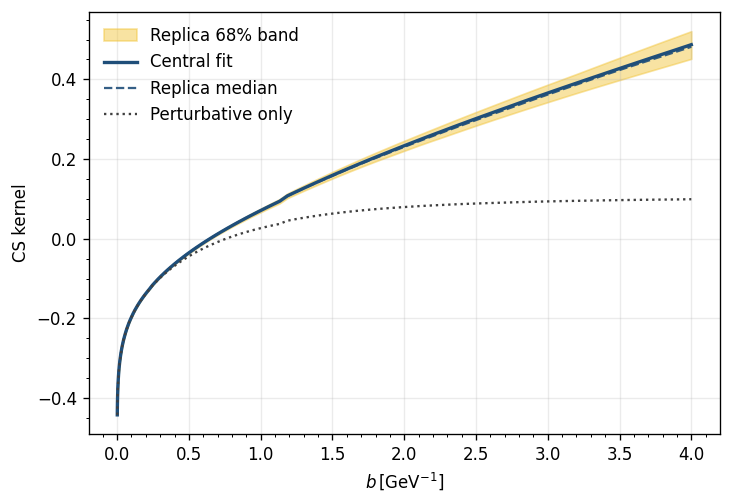

Wrote preview plot to C:\Users\congyue zhang\Desktop\OpenCL fitter\TMD-Fits-Minimal\Replica Analysis\CS kernel\Final_old_replica_0325_CS_band_preview.pdf


In [7]:
if show_plot:
    fig, ax = plt.subplots(figsize=(6.2, 4.3))
    ax.fill_between(
        b_grid,
        kernel_band_df["CS_band_lo_68"].to_numpy(dtype=float),
        kernel_band_df["CS_band_hi_68"].to_numpy(dtype=float),
        color="#F1C232",
        alpha=0.45,
        label="Replica 68% band",
    )
    ax.plot(
        b_grid,
        kernel_band_df["CS_central"].to_numpy(dtype=float),
        color="#1F4E79",
        linewidth=2.0,
        label="Central fit",
    )
    ax.plot(
        b_grid,
        kernel_band_df["CS_replica_median"].to_numpy(dtype=float),
        color="#1F4E79",
        linestyle="--",
        linewidth=1.35,
        alpha=0.9,
        label="Replica median",
    )
    ax.plot(
        b_grid,
        kernel_band_df["CS_Pert"].to_numpy(dtype=float),
        color="0.25",
        linestyle=":",
        linewidth=1.4,
        label="Perturbative only",
    )
    ax.set_xlabel(r"$b\,[\mathrm{GeV}^{-1}]$")
    ax.set_ylabel("CS kernel")
    ax.grid(alpha=0.25)
    ax.minorticks_on()
    ax.legend(frameon=False)
    fig.tight_layout()
    fig.savefig(preview_plot_path, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"Wrote preview plot to {preview_plot_path}")
else:
    print("show_plot = False; skipping preview plot.")


In [8]:
kernel_band_df.to_csv(output_band_csv_path, index=False)
display(kernel_band_df.head(10))
print(f"Wrote {len(kernel_band_df)} rows to {output_band_csv_path}")


,b,Q,CS_Pert,CS_NP_central,CS_central,CS_replica_median,CS_band_lo_68,CS_band_hi_68
0,0.001000,2.0,-0.442049,1.368086e-07,-0.442049,-0.442049,-0.442049,-0.442049
1,0.001004,2.0,-0.441888,1.378214e-07,-0.441888,-0.441888,-0.441888,-0.441888
2,0.001033,2.0,-0.440770,1.450029e-07,-0.440770,-0.440770,-0.440770,-0.440770
3,0.001111,2.0,-0.437856,1.652783e-07,-0.437856,-0.437856,-0.437856,-0.437856
4,0.001264,2.0,-0.432637,2.079610e-07,-0.432637,-0.432637,-0.432637,-0.432637
5,0.001515,2.0,-0.425876,2.871932e-07,-0.425876,-0.425876,-0.425876,-0.425876
6,0.001890,2.0,-0.417070,4.246903e-07,-0.417070,-0.417070,-0.417071,-0.417070
7,0.002414,2.0,-0.406541,6.523198e-07,-0.406542,-0.406542,-0.406542,-0.406541
8,0.003110,2.0,-0.395949,1.014006e-06,-0.395950,-0.395950,-0.395950,-0.395950
9,0.004005,2.0,-0.384862,1.566787e-06,-0.384864,-0.384864,-0.384864,-0.384863


Wrote 100 rows to C:\Users\congyue zhang\Desktop\OpenCL fitter\TMD-Fits-Minimal\Replica Analysis\extracted CS\replica_0325.csv
